1. Setup and Data Preparation

In [ ]:
from pathlib import Path
import sys
import importlib
import pandas as pd
from pathlib import Path

# Manually set project root for this notebook
PROJECT_ROOT = Path(r"C:\Users\k454047\OneDrive - Air France KLM\Desktop\THESIS\Code Test")

SRC_HELPERS = PROJECT_ROOT / "src" / "KLM" / "helpers"
if str(SRC_HELPERS) not in sys.path:
    sys.path.insert(0, str(SRC_HELPERS))

# import eda_helpers as eda
# import feature_creators_der as creator_der
# importlib.reload(eda)
# importlib.reload(creator_der)

DATA_PATH = PROJECT_ROOT / "data" / "klm" / "target_2023-2025_NOV_featured_RECENT_with_arrival_pressure.parquet"
FIG_DIR = PROJECT_ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

import logging

# Get your module logger or root logger
logger = logging.getLogger()  # or logging.getLogger("creator_der") if you use named loggers

# If no handlers, add a console handler
if not logger.handlers:
    handler = logging.StreamHandler()
    formatter = logging.Formatter(
        "%(asctime)s [%(levelname)s] %(name)s - %(message)s",
        datefmt="%H:%M:%S",
    )
    handler.setFormatter(formatter)
    logger.addHandler(handler)

logger.setLevel(logging.INFO)

In [ ]:
from google.cloud import bigquery

client = bigquery.Client()

query = """YOUR SQL QUERY HERE"""

df = client.query(query).to_dataframe()

In [1]:
# Core packages
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Date handling
from datetime import timedelta
from pathlib import Path

# Big Query initialization
from google.cloud import bigquery
client = bigquery.Client()

# Settings
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

c:\Users\k454047\OneDrive - Air France KLM\Desktop\THESIS\Code Test\.venv\Lib\site-packages\google\auth\_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)
c:\Users\k454047\OneDrive - Air France KLM\Desktop\THESIS\Code Test\.venv\Lib\site-packages\google\auth\_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


2. Load and Initial Inspection

In [ ]:
# Get query path from file
query_path = "queries/test.sql"
with open(query_path, "r", encoding="utf-8") as f:
    query = f.read()

# Execute the query
# client = bigquery.Client()  # You can also reuse the existing client if you have already initialized it
res_df = client.query(query).to_dataframe()

display(res_df)

In [2]:
# Option A: Parquet (preferred)
PROJECT_ROOT = Path(r"C:\Users\k454047\OneDrive - Air France KLM\Desktop\THESIS\Code Test")
input_path = PROJECT_ROOT / "data" / "raw" / "klm_raw_2023_2026.parquet"
df = pd.read_parquet(input_path)

# Option B: CSV (needs extra care)
# df = pd.read_csv("testdata.csv", low_memory=False)

df_clean = df.copy()

print("Shape:", df_clean.shape)
display(df_clean.head())
display(df_clean.info())
df_clean.describe()

Shape: (618519, 57)


,flight_leg_key,fl_flight_plan_version,fl_scheduled_departure_date_utc,fl_scheduled_arrival_date_utc,fl_season,fl_airline,fl_flight_number,fl_flight_code,fl_service_type,fl_flight_product,fl_city_pair,fl_direction,fl_departure_airport,fl_departure_airport_icao_code,fl_departure_airport_latitude,fl_departure_airport_longitude,fl_actual_arrival_airport,fl_planned_arrival_airport,fl_arrival_airport_icao_code,fl_arrival_airport_latitude,fl_arrival_airport_longitude,fl_aircraft_type,fl_aircraft_subtype,fl_aircraft_registration,fl_aircraft_owner,fl_scheduled_off_block_time_utc,fl_actual_off_block_time_utc,fl_scheduled_in_block_time_utc,fl_actual_in_block_time_utc,fl_scheduled_block_time_min,fl_actual_block_time_min,fl_actual_taxi_out_duration_min,fl_flight_plan_trip_duration_min,fl_actual_trip_duration_min,fl_actual_taxi_in_duration_min,fl_departure_delay_difference_min,fl_block_delay_difference_min,fl_arrival_delay_difference_min,fl_star,fl_departure_runway,fl_arrival_runway,fl_actual_touchdown_time_utc,fl_prev_leg,fl_prev_leg_sibt_utc,fl_prev_leg_aibt_utc,fl_prev_leg_arrival_delay_min,fl_trip_duration_deviation_min,fp_flight_plan_version,fp_flight_plan_timestamp_utc,fp_planned_arrival_runway,fl_great_circle_distance_nm,fp_cost_index,fp_route_waypoints,fl_estimated_touchdown_time_utc,fl_actual_touchdown_time_utc_1,fl_touchdown_delay_min,has_flight_plan_data
0,2024-04-13|KL|0765||BON,9,2024-04-13,2024-04-14,S24,KL,765,KL0765,J,ICA,BON-AMS,AMS-IN,BON,TNCB,12.129727,-68.267921,AMS,AMS,EHAM,52.305528,4.767009,330,333,PHAKB,KL,2024-04-14 01:15:00,2024-04-14 01:11:00,2024-04-14 10:40:00,2024-04-14 10:14:00,565,543,10,529,531,2,-4,-22,-26,REDFA1A,10,36R,2024-04-14 10:12:00,2024-04-13|KL|0765||AUA,2024-04-13 23:59:00+00:00,2024-04-14 00:12:00+00:00,13,2,9,2024-04-13 23:49:51.023000+00:00,36R,4208,10,"TNCB,ACORA,SILVA,T_O_C,ILMET,MILOK,RAYAS,RAFEE...",2024-04-14 10:12:00+00:00,2024-04-14 10:12:00+00:00,0,1
1,2025-03-18|KL|0751||GYE,14,2025-03-18,2025-03-19,W24,KL,751,KL0751,J,ICA,GYE-AMS,AMS-IN,GYE,SEGU,-2.159840,-79.870317,AMS,AMS,EHAM,52.305528,4.767009,777,772,PHBQD,KL,2025-03-19 01:05:00,2025-03-19 01:27:00,2025-03-19 12:25:00,2025-03-19 12:36:00,680,669,11,652,651,7,22,-11,11,DCT,21,18R,2025-03-19 12:29:00,2025-03-18|KL|0751||UIO,2025-03-18 23:30:00+00:00,2025-03-18 23:23:00+00:00,-7,-1,14,2025-03-18 23:14:16.896000+00:00,18R,5311,200,"SEGU,T_O_C,UGUPI,ANRON,SATMI,T_O_S,OROSA,IRBAR...",2025-03-19 12:28:00+00:00,2025-03-19 12:29:00+00:00,1,1
2,2024-01-11|KL|0765||BON,17,2024-01-11,2024-01-12,W23,KL,765,KL0765,J,ICA,BON-AMS,AMS-IN,BON,TNCB,12.129727,-68.267921,AMS,AMS,EHAM,52.305528,4.767009,330,333,PHAKB,KL,2024-01-12 01:25:00,2024-01-12 00:58:00,2024-01-12 10:45:00,2024-01-12 10:37:00,560,579,9,554,562,8,-27,19,-8,DCT,10,06,2024-01-12 10:29:00,2024-01-11|KL|0765||AUA,2024-01-12 00:05:00+00:00,2024-01-11 23:50:00+00:00,-15,8,17,2024-01-12 00:11:40.612000+00:00,06,4208,200,"TNCB,ACORA,T_O_C,MILOK,RAYAS,RAFEE,ANNER,PORQE...",2024-01-12 10:29:00+00:00,2024-01-12 10:29:00+00:00,0,1
3,2024-07-12|KL|0767||BON,11,2024-07-12,2024-07-13,S24,KL,767,KL0767,J,ICA,BON-AMS,AMS-IN,BON,TNCB,12.129727,-68.267921,AMS,AMS,EHAM,52.305528,4.767009,330,333,PHAKB,KL,2024-07-13 01:15:00,2024-07-13 01:31:00,2024-07-13 10:55:00,2024-07-13 10:41:00,580,550,10,539,528,12,16,-30,-14,DCT,10,18R,2024-07-13 10:29:00,2024-07-12|KL|0767||AUA,NaT,NaT,<NA>,-11,11,2024-07-13 00:07:17.174000+00:00,18R,4208,200,"TNCB,ACORA,T_O_C,MILOK,DAWIN,ENTRY1,KAVAX,ETP1...",2024-07-13 10:30:00+00:00,2024-07-13 10:29:00+00:00,-1,1
4,2023-12-26|KL|1546||LBA,<NA>,2023-12-26,2023-12-26,W23,KL,1546,KL1546,J,KLC,LBA-AMS,AMS-IN,LBA,EGNM,53.863973,-1.650118,AMS,AMS,EHAM,52.305528,4.767009,EMJ,E90,DACJJ,ZQ,2023-12-26 10:00:00,2023-12-26 10:06:00,2023-12-26 11:15:00,2023-12-26 11:08:00,75,62,9,<NA>,48,5,6,-13,-7,NaN,NaN,NaN,2023-12-26 11:03:00,2023-12-26|KL|1545||AMS,NaT,NaT,<NA>,<NA>,<NA>,NaT,NaN,<NA>,<NA>,NaN,2023-12-26 11:03:00+00:00,2023-12-26 11:03:00+00:00,0,0


<class 'pandas.DataFrame'>
RangeIndex: 618519 entries, 0 to 618518
Data columns (total 57 columns):
 #   Column                             Non-Null Count   Dtype              
---  ------                             --------------   -----              
 0   flight_leg_key                     618519 non-null  str                
 1   fl_flight_plan_version             566125 non-null  Int64              
 2   fl_scheduled_departure_date_utc    618519 non-null  dbdate             
 3   fl_scheduled_arrival_date_utc      618494 non-null  dbdate             
 4   fl_season                          618519 non-null  str                
 5   fl_airline                         618519 non-null  str                
 6   fl_flight_number                   618519 non-null  Int64              
 7   fl_flight_code                     618519 non-null  str                
 8   fl_service_type                    618519 non-null  str                
 9   fl_flight_product                  618519 non-nu

None

,fl_flight_plan_version,fl_flight_number,fl_departure_airport_latitude,fl_departure_airport_longitude,fl_arrival_airport_latitude,fl_arrival_airport_longitude,fl_scheduled_off_block_time_utc,fl_actual_off_block_time_utc,fl_scheduled_in_block_time_utc,fl_actual_in_block_time_utc,fl_scheduled_block_time_min,fl_actual_block_time_min,fl_actual_taxi_out_duration_min,fl_flight_plan_trip_duration_min,fl_actual_trip_duration_min,fl_actual_taxi_in_duration_min,fl_departure_delay_difference_min,fl_block_delay_difference_min,fl_arrival_delay_difference_min,fl_actual_touchdown_time_utc,fl_prev_leg_arrival_delay_min,fl_trip_duration_deviation_min,fp_flight_plan_version,fl_great_circle_distance_nm,fp_cost_index,fl_touchdown_delay_min,has_flight_plan_data
count,566125.0,618519.0,618519.000000,618519.000000,618519.000000,618519.000000,618519,618481,618494,618461,618491.0,618437.0,618274.0,566125.0,617923.0,617969.0,618481.0,618410.0,618436.0,617992,568738.0,565600.0,567654.0,567313.0,561176.0,617889.0,618519.0
mean,148.501999,1347.284447,49.184618,3.955130,49.189593,3.952357,2024-12-31 03:35:23.194598,2024-12-31 03:53:59.217016,2024-12-31 06:40:31.826502,2024-12-31 06:23:43.463209,168.324664,161.961788,13.054927,154.022006,142.311348,6.590814,16.048509,-6.346616,9.708235,2024-12-31 04:56:31.465068,9.107106,-3.873059,148.150948,1015.119394,35.802745,-0.355718,0.917763
min,1.0,417.0,-34.824164,-123.180196,-34.824164,-123.180196,2023-10-01 00:45:00,2023-10-01 00:46:00,2023-10-01 05:00:00,2023-10-01 04:53:00,-2400.0,-619.0,-670.0,21.0,-1420.0,-2820.0,-585.0,-1259.0,-592.0,2023-10-01 04:41:00,-3885.0,-1584.0,1.0,0.0,0.0,-1598.0,0.0
25%,12.0,1024.0,50.036615,4.767009,50.036615,4.767009,2024-05-23 10:25:00,2024-05-23 10:35:00,2024-05-23 13:20:00,2024-05-23 12:31:00,80.0,74.0,10.0,62.0,55.0,4.0,1.0,-12.0,-6.0,2024-05-23 11:37:00,-6.0,-7.0,12.0,320.0,11.0,-1.0,1.0
50%,19.0,1319.0,52.305528,4.767009,52.305528,4.767009,2024-12-31 09:00:00,2024-12-31 09:08:00,2024-12-31 11:12:30,2024-12-31 10:47:00,100.0,94.0,12.0,85.0,75.0,5.0,8.0,-6.0,2.0,2024-12-31 09:14:30,2.0,-4.0,19.0,456.0,20.0,0.0,1.0
75%,505.0,1664.0,52.305528,7.213539,52.305528,7.213539,2025-08-10 18:45:00,2025-08-10 18:55:00,2025-08-10 20:58:45,2025-08-10 20:46:00,130.0,128.0,15.0,117.0,108.0,9.0,20.0,-1.0,15.0,2025-08-10 20:40:15,14.0,-1.0,505.0,700.0,30.0,1.0,1.0
max,620.0,9979.0,67.666526,140.386119,67.666526,140.386119,2026-04-01 01:20:00,2026-04-01 01:52:00,2026-04-01 11:15:00,2026-04-01 11:04:00,1895.0,2078.0,2844.0,949.0,956.0,1581.0,5848.0,2921.0,5834.0,2026-04-01 10:47:00,3163.0,448.0,620.0,6482.0,800.0,453.0,1.0
std,219.672449,544.489022,11.016368,23.447326,11.001044,23.422822,NaN,NaN,NaN,NaN,181.02711,179.783535,10.604597,180.978753,176.944093,10.377557,42.766845,11.473299,44.169343,NaN,40.33287,6.623909,219.491575,1413.031427,50.467743,12.817223,0.274725


In [3]:
# Print all aircraft owner names and percentage of missing flight plan data for each
owner_stats = df_clean.groupby('fl_aircraft_owner')['has_flight_plan_data'].agg(['mean', 'count']).reset_index()
owner_stats['missing_fp_pct'] = (1 - owner_stats['mean']) * 100
owner_stats = owner_stats.sort_values(by='missing_fp_pct', ascending=False)
print(owner_stats[['fl_aircraft_owner', 'missing_fp_pct', 'count']])

  fl_aircraft_owner  missing_fp_pct   count
0                A5           100.0    3445
7                ZQ           100.0   33125
5                T3           100.0   11437
4                P6           100.0    1381
1                AF       99.378882     161
3                KL        0.252857  287910
2                HV          0.2414    1657
6                WA        0.209375  279403


In [4]:
# Filter for flights with service type J, aircraft owner is KL or WA and non-zero has_flight_plan_data
df_clean = df_clean[
    (df_clean['fl_service_type'] == 'J') &
    # (df_clean['fl_aircraft_owner'].isin(['KL', 'WA'])) &
    (df_clean['has_flight_plan_data'] != 0)
]

print("Shape after filtering for flights with service type J and non-zero flight plan data", df_clean.shape)

# Replace common "fake nulls"
obj_cols = df_clean.select_dtypes(include=["object", "string"]).columns
df_clean[obj_cols] = df_clean[obj_cols].replace(["NULL", "None", "", "NaN"], np.nan)
df_clean = df_clean.replace(r'^\s*$', np.nan, regex=True)

print("\nMissing values (%):") #show top 20 columns with most missing values
print((df_clean.isnull().mean() * 100).sort_values(ascending=False).head(20))

print("\nData types:")
print(df_clean.dtypes)

Shape after filtering for flights with service type J and non-zero flight plan data (566106, 57)

Missing values (%):
fl_prev_leg_arrival_delay_min       1.661173
fl_prev_leg_sibt_utc                1.578326
fl_prev_leg_aibt_utc                1.399208
fp_cost_index                       1.142719
fl_trip_duration_deviation_min      0.377138
fl_star                             0.303123
fl_departure_runway                 0.292878
fl_flight_plan_trip_duration_min    0.292171
fl_flight_plan_version              0.292171
fl_arrival_runway                   0.292171
fl_great_circle_distance_nm         0.291995
fl_prev_leg                         0.279630
fl_touchdown_delay_min              0.086203
fl_actual_trip_duration_min         0.085320
fl_actual_taxi_in_duration_min      0.083907
fl_actual_touchdown_time_utc        0.080904
fl_actual_touchdown_time_utc_1      0.079667
fl_actual_taxi_out_duration_min     0.024730
fl_estimated_touchdown_time_utc     0.019431
fl_block_delay_difference_m

3. Data Type Fixing and Feature Creation

In [5]:
datetime_cols = [
    'fl_scheduled_departure_date_utc',
    'fl_scheduled_arrival_date_utc',
    'fl_scheduled_off_block_time_utc',
    'fl_actual_off_block_time_utc',
    'fl_scheduled_in_block_time_utc',
    'fl_actual_in_block_time_utc',
    'fp_flight_plan_timestamp_utc',
    'fl_estimated_touchdown_time_utc',
    'fl_actual_touchdown_time_utc',
    'fl_prev_leg_sibt_utc',
    'fl_prev_leg_aibt_utc'
]

for col in datetime_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')

# Time-based features
df_clean['departure_hour'] = df_clean['fl_scheduled_off_block_time_utc'].dt.hour
df_clean['departure_dayofweek'] = df_clean['fl_scheduled_off_block_time_utc'].dt.day_name()
df_clean['departure_month'] = df_clean['fl_scheduled_off_block_time_utc'].dt.month
df_clean['arrival_hour'] = df_clean['fl_scheduled_in_block_time_utc'].dt.hour
df_clean['arrival_dayofweek'] = df_clean['fl_scheduled_in_block_time_utc'].dt.day_name()
df_clean['arrival_month'] = df_clean['fl_scheduled_in_block_time_utc'].dt.month
df_clean['actual_arrival_hour'] = df_clean['fl_actual_in_block_time_utc'].dt.hour
df_clean['actual_arrival_dayofweek'] = df_clean['fl_actual_in_block_time_utc'].dt.day_name()
df_clean['actual_arrival_month'] = df_clean['fl_actual_in_block_time_utc'].dt.month
df_clean['estimated_touchdown_hour'] = df_clean['fl_estimated_touchdown_time_utc'].dt.hour
df_clean['estimated_touchdown_dayofweek'] = df_clean['fl_estimated_touchdown_time_utc'].dt.day_name()
df_clean['estimated_touchdown_month'] = df_clean['fl_estimated_touchdown_time_utc'].dt.month
df_clean['actual_touchdown_hour'] = df_clean['fl_actual_touchdown_time_utc'].dt.hour
df_clean['actual_touchdown_dayofweek'] = df_clean['fl_actual_touchdown_time_utc'].dt.day_name()
df_clean['actual_touchdown_month'] = df_clean['fl_actual_touchdown_time_utc'].dt.month
df_clean['prev_scheduled_arrival_hour'] = df_clean['fl_prev_leg_sibt_utc'].dt.hour
df_clean['prev_scheduled_arrival_dayofweek'] = df_clean['fl_prev_leg_sibt_utc'].dt.day_name()
df_clean['prev_scheduled_arrival_month'] = df_clean['fl_prev_leg_sibt_utc'].dt.month
df_clean['prev_actual_arrival_hour'] = df_clean['fl_prev_leg_aibt_utc'].dt.hour
df_clean['prev_actual_arrival_dayofweek'] = df_clean['fl_prev_leg_aibt_utc'].dt.day_name()
df_clean['prev_actual_arrival_month'] = df_clean['fl_prev_leg_aibt_utc'].dt.month

df_clean['fp_flight_plan_timestamp_utc'] = (df_clean['fp_flight_plan_timestamp_utc'].dt.tz_localize(None))

df_clean['fp_lead_time_min'] = (
    (df_clean['fp_flight_plan_timestamp_utc'] - df_clean['fl_scheduled_off_block_time_utc'])
    .dt.total_seconds() / 60)

df_clean['fp_lead_time_min'].describe()

# Delay features
# df_clean['departure_delay_min'] = (
#     (df_clean['fl_actual_off_block_time_utc'] - df_clean['fl_scheduled_off_block_time_utc'])
#     .dt.total_seconds() / 60
# )

# df_clean['arrival_delay_min'] = (
#     (df_clean['fl_actual_in_block_time_utc'] - df_clean['fl_scheduled_in_block_time_utc'])
#     .dt.total_seconds() / 60
# )

# Flight duration consistency check
# df_clean['calculated_block_time_min'] = (
#     (df_clean['fl_actual_in_block_time_utc'] - df_clean['fl_actual_off_block_time_utc'])
#     .dt.total_seconds() / 60
# )

count    566106.000000
mean       -119.937319
std          48.113915
min       -1608.616183
25%        -134.091317
50%        -130.199875
75%        -102.622608
max        5579.032383
Name: fp_lead_time_min, dtype: float64

In [6]:
# Print number of flights with positive lead time
positive_lead_time_count = (df_clean['fp_lead_time_min'] > 0).sum()
print(f"Number of flights with positive lead time: {positive_lead_time_count}")

Number of flights with positive lead time: 7368


4. Filter Block and Trip Time Deviation

Schiphol arrivals with block time difference and trip time deviation <= 60 min: (563274, 79)


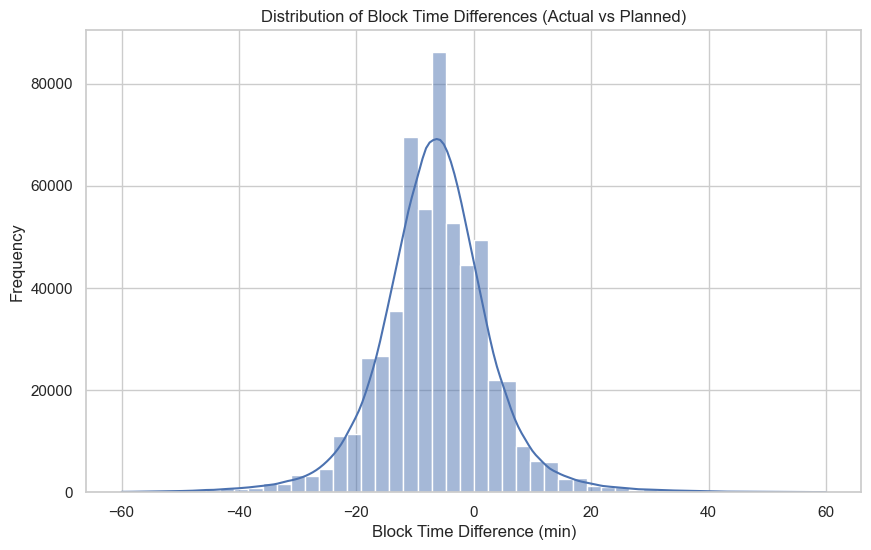

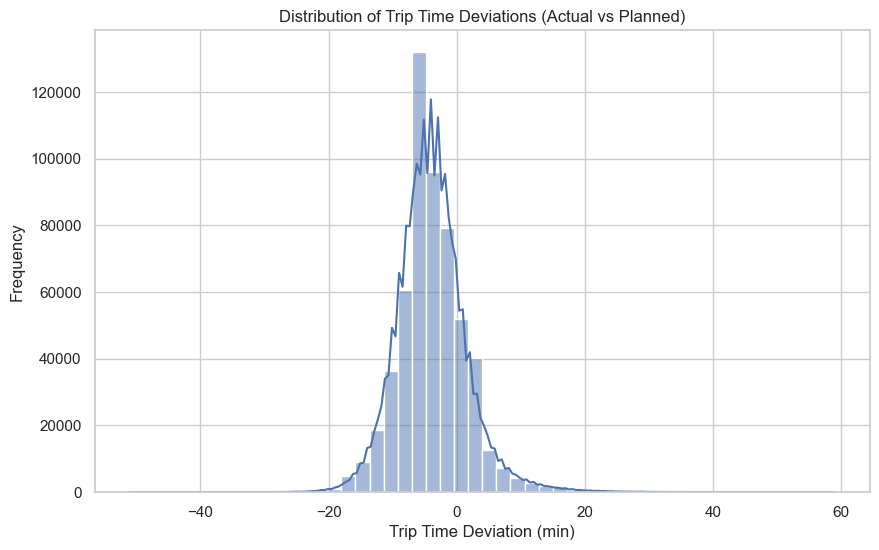

,fl_flight_plan_version,fl_scheduled_departure_date_utc,fl_scheduled_arrival_date_utc,fl_flight_number,fl_departure_airport_latitude,fl_departure_airport_longitude,fl_arrival_airport_latitude,fl_arrival_airport_longitude,fl_scheduled_off_block_time_utc,fl_actual_off_block_time_utc,fl_scheduled_in_block_time_utc,fl_actual_in_block_time_utc,fl_scheduled_block_time_min,fl_actual_block_time_min,fl_actual_taxi_out_duration_min,fl_flight_plan_trip_duration_min,fl_actual_trip_duration_min,fl_actual_taxi_in_duration_min,fl_departure_delay_difference_min,fl_block_delay_difference_min,fl_arrival_delay_difference_min,fl_actual_touchdown_time_utc,fl_prev_leg_arrival_delay_min,fl_trip_duration_deviation_min,fp_flight_plan_version,fp_flight_plan_timestamp_utc,fl_great_circle_distance_nm,fp_cost_index,fl_touchdown_delay_min,has_flight_plan_data,departure_hour,departure_month,arrival_hour,arrival_month,actual_arrival_hour,actual_arrival_month,estimated_touchdown_hour,estimated_touchdown_month,actual_touchdown_hour,actual_touchdown_month,prev_scheduled_arrival_hour,prev_scheduled_arrival_month,prev_actual_arrival_hour,prev_actual_arrival_month,fp_lead_time_min
count,563274.0,563274,563274,563274.0,563274.000000,563274.000000,563274.000000,563274.000000,563274,563274,563274,563273,563274.0,563274.0,563274.0,563274.0,563274.0,563273.0,563274.0,563274.0,563273.0,563274,554022.0,563274.0,563274.0,563274,563274.0,556891.0,563240.0,563274.0,563274.000000,563274.000000,563274.000000,563274.000000,563273.000000,563273.000000,563240.000000,563240.000000,563274.000000,563274.000000,554481.000000,554481.000000,555498.000000,555498.000000,563274.000000
mean,148.637532,2024-12-28 03:36:47,2024-12-28 05:23:44,1320.283999,48.968210,3.911479,48.952238,3.907661,2024-12-28 16:00:59.532910,2024-12-28 16:16:14.975341,2024-12-28 18:57:08.496042,2024-12-28 19:05:00.988402,176.149386,169.582903,13.105045,153.731616,149.862275,6.615565,15.257374,-6.566483,8.690965,2024-12-28 18:59:13.014518,8.780496,-3.869341,148.6372,2024-12-28 14:01:02.643067,1012.741804,35.738197,-0.246536,1.0,11.894838,6.600493,13.077673,6.599983,13.159812,6.599997,13.081585,6.600133,13.075196,6.600035,13.088569,6.604463,13.181628,6.603948,-119.948164
min,1.0,2023-10-01 00:00:00,2023-10-01 00:00:00,417.0,-34.824164,-123.180196,-34.824164,-123.180196,2023-10-01 00:45:00,2023-10-01 00:46:00,2023-10-01 05:00:00,2023-10-01 04:53:00,40.0,27.0,-136.0,24.0,6.0,-2820.0,-350.0,-60.0,-396.0,2023-10-01 04:41:00,-3885.0,-51.0,1.0,2023-09-30 19:16:09.118000,85.0,0.0,-1576.0,1.0,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,-1608.616183
25%,12.0,2024-05-18 00:00:00,2024-05-18 00:00:00,1020.0,50.036615,4.767009,49.624085,4.767009,2024-05-18 06:46:15,2024-05-18 06:54:00,2024-05-18 09:05:00,2024-05-18 08:57:00,80.0,77.0,10.0,62.0,58.0,4.0,1.0,-12.0,-6.0,2024-05-18 08:55:00,-6.0,-7.0,12.0,2024-05-18 04:51:03.735000,320.0,11.0,-1.0,1.0,8.000000,3.000000,9.000000,3.000000,9.000000,3.000000,9.000000,3.000000,9.000000,3.000000,9.000000,3.000000,9.000000,3.000000,-134.082496
50%,19.0,2024-12-26 00:00:00,2024-12-26 00:00:00,1313.0,52.305528,4.767009,52.305528,4.767009,2024-12-26 15:55:00,2024-12-26 16:02:00,2024-12-26 18:35:00,2024-12-26 18:42:00,105.0,97.0,12.0,85.0,79.0,5.0,8.0,-7.0,2.0,2024-12-26 18:36:00,2.0,-4.0,19.0,2024-12-26 13:56:10.854500,456.0,20.0,0.0,1.0,12.000000,7.000000,13.000000,7.000000,13.000000,7.000000,13.000000,7.000000,13.000000,7.000000,13.000000,7.000000,13.000000,7.000000,-130.188192
75%,505.0,2025-08-11 00:00:00,2025-08-11 00:00:00,1642.0,52.305528,7.213539,52.305528,7.213539,2025-08-11 04:00:00,2025-08-11 04:11:00,2025-08-11 06:30:00,2025-08-11 06:28:00,140.0,133.0,15.0,117.0,113.0,9.0,19.0,-1.0,14.0,2025-08-11 06:20:30,14.0,-1.0,505.0,2025-08-11 01:56:37.945000,700.0,30.0,2.0,1.0,16.000000,10.000000,18.000000,10.000000,18.000000,10.000000,18.000000,10.000000,18.000000,10.000000,17.000000,10.000000,18.000000,10.00

In [7]:
# # Print flights with highest block delay difference
# df_sorted = df_clean.sort_values(by='fl_block_delay_difference_min', ascending=False)
# print("Top 10 Schiphol arrivals with highest block time difference:")
# display(df_sorted[['flight_leg_key', 'fl_block_delay_difference_min']].head(20))

# Filter for flights with block delay difference and trip time deviation < 60 min
df_clean = df_clean[(df_clean['fl_block_delay_difference_min'].abs() <= 60) & (df_clean['fl_trip_duration_deviation_min'].abs() <= 60)].copy()
print("Schiphol arrivals with block time difference and trip time deviation <= 60 min:", df_clean.shape)

# Show distribution of block time differences
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['fl_block_delay_difference_min'], bins=50, kde=True)
plt.title('Distribution of Block Time Differences (Actual vs Planned)')
plt.xlabel('Block Time Difference (min)')
plt.ylabel('Frequency')
plt.show()

# Show distribution of trip time deviations
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['fl_trip_duration_deviation_min'], bins=50, kde=True)
plt.title('Distribution of Trip Time Deviations (Actual vs Planned)')
plt.xlabel('Trip Time Deviation (min)')
plt.ylabel('Frequency')
plt.show()

df_clean.describe()

Remove top and bottom 1% of data (outliers)

In [8]:
# Remove flights which have data in top and bottom 1% of data (potential outliers) 
cols_to_filter = [
    'fl_actual_taxi_out_duration_min',
    'fl_actual_taxi_in_duration_min',
    'fl_departure_delay_difference_min',
    'fl_arrival_delay_difference_min',
    'fl_prev_leg_arrival_delay_min',
    'fl_touchdown_delay_min' 
]

df_filtertest = df_clean.copy()

for col in cols_to_filter:
    bottom1 = df_filtertest[col].quantile(0.01)
    top1 = df_filtertest[col].quantile(0.99)

    # Remove rows where the value in the column is below the 1st percentile or above the 99th percentile
    df_filtertest = df_filtertest[
        (df_filtertest[col] >= bottom1) & (df_filtertest[col] <= top1)
    ].copy()

print(f"After filtering {col} for top and bottom 1% values: {df_filtertest.shape}")
df_filtertest.describe()

After filtering fl_touchdown_delay_min for top and bottom 1% values: (500666, 79)


,fl_flight_plan_version,fl_scheduled_departure_date_utc,fl_scheduled_arrival_date_utc,fl_flight_number,fl_departure_airport_latitude,fl_departure_airport_longitude,fl_arrival_airport_latitude,fl_arrival_airport_longitude,fl_scheduled_off_block_time_utc,fl_actual_off_block_time_utc,fl_scheduled_in_block_time_utc,fl_actual_in_block_time_utc,fl_scheduled_block_time_min,fl_actual_block_time_min,fl_actual_taxi_out_duration_min,fl_flight_plan_trip_duration_min,fl_actual_trip_duration_min,fl_actual_taxi_in_duration_min,fl_departure_delay_difference_min,fl_block_delay_difference_min,fl_arrival_delay_difference_min,fl_actual_touchdown_time_utc,fl_prev_leg_arrival_delay_min,fl_trip_duration_deviation_min,fp_flight_plan_version,fp_flight_plan_timestamp_utc,fl_great_circle_distance_nm,fp_cost_index,fl_touchdown_delay_min,has_flight_plan_data,departure_hour,departure_month,arrival_hour,arrival_month,actual_arrival_hour,actual_arrival_month,estimated_touchdown_hour,estimated_touchdown_month,actual_touchdown_hour,actual_touchdown_month,prev_scheduled_arrival_hour,prev_scheduled_arrival_month,prev_actual_arrival_hour,prev_actual_arrival_month,fp_lead_time_min
count,500666.0,500666,500666,500666.0,500666.000000,500666.000000,500666.000000,500666.000000,500666,500666,500666,500666,500666.0,500666.0,500666.0,500666.0,500666.0,500666.0,500666.0,500666.0,500666.0,500666,500666.0,500666.0,500666.0,500666,500666.0,494808.0,500666.0,500666.0,500666.000000,500666.000000,500666.000000,500666.000000,500666.000000,500666.000000,500666.000000,500666.000000,500666.000000,500666.000000,500666.000000,500666.000000,500666.000000,500666.000000,500666.000000
mean,152.114843,2024-12-27 02:08:04,2024-12-27 03:34:21,1340.704837,49.330356,4.676169,49.278872,4.190891,2024-12-27 14:27:27.185668,2024-12-27 14:40:00.264607,2024-12-27 17:11:03.753760,2024-12-27 17:16:54.322562,163.609468,156.900966,12.69825,141.88314,137.795534,6.407182,12.551316,-6.708502,5.842813,2024-12-27 17:10:29.891664,6.28221,-4.087605,152.11447,2024-12-27 12:25:46.880319,917.516105,33.81626,-0.196914,1.0,11.845879,6.614833,13.132300,6.614509,13.190438,6.614501,13.106053,6.614484,13.100914,6.614486,13.099979,6.615676,13.160388,6.615666,-121.671756
min,1.0,2023-10-01 00:00:00,2023-10-01 00:00:00,417.0,-34.824164,-123.180196,-34.824164,-123.180196,2023-10-01 00:45:00,2023-10-01 00:46:00,2023-10-01 05:00:00,2023-10-01 04:53:00,40.0,28.0,6.0,24.0,18.0,2.0,-12.0,-60.0,-27.0,2023-10-01 04:41:00,-29.0,-47.0,1.0,2023-09-30 20:07:12.933000,85.0,0.0,-12.0,1.0,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,-1608.616183
25%,12.0,2024-05-18 00:00:00,2024-05-18 00:00:00,1047.0,50.036615,4.767009,50.082451,4.767009,2024-05-18 13:20:00,2024-05-18 13:39:00,2024-05-18 16:51:15,2024-05-18 16:58:15,80.0,76.0,9.0,62.0,58.0,4.0,1.0,-12.0,-6.0,2024-05-18 16:53:15,-6.0,-7.0,12.0,2024-05-18 11:15:14.525250,320.0,11.0,-1.0,1.0,8.000000,3.000000,9.000000,3.000000,9.000000,3.000000,9.000000,3.000000,9.000000,3.000000,9.000000,3.000000,9.000000,3.000000,-134.110179
50%,20.0,2024-12-24 00:00:00,2024-12-24 00:00:00,1328.0,52.305528,4.767009,52.305528,4.767009,2024-12-24 10:55:00,2024-12-24 11:01:30,2024-12-24 13:05:00,2024-12-24 13:10:30,100.0,96.0,12.0,83.0,78.0,5.0,7.0,-7.0,2.0,2024-12-24 13:02:30,2.0,-4.0,20.0,2024-12-24 08:44:15.759500,448.0,20.0,0.0,1.0,12.000000,7.000000,13.000000,7.000000,13.000000,7.000000,13.000000,7.000000,13.000000,7.000000,13.000000,7.000000,13.000000,7.000000,-130.571117
75%,506.0,2025-08-07 00:00:00,2025-08-07 00:00:00,1653.0,52.305528,7.648987,52.305528,7.528665,2025-08-07 18:30:00,2025-08-07 18:42:30,2025-08-07 20:35:00,2025-08-07 20:44:00,130.0,127.0,15.0,112.0,108.0,9.0,18.0,-2.0,13.0,2025-08-07 20:36:30,13.0,-1.0,506.0,2025-08-07 16:25:18.074750,670.0,30.0,1.0,1.0,16.000000,10.000000,17.000000,10.000000,18.000000,10.000000,17.000000,10.000000,17.000000,10.000000,17.000000,10.000000,18.000000,10.000000,-104.900929


In [ ]:
for col in cols_to_filter:
    plt.figure(figsize=(8,4))
    sns.histplot(df_filtertest[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [ ]:
# numeric_cols = [
#     'fl_scheduled_block_time_min',
#     'fl_actual_block_time_min',
#     'fl_actual_taxi_out_duration_min',
#     'fl_flight_plan_trip_duration_min',
#     'fl_actual_trip_duration_min',
#     'fl_actual_taxi_in_duration_min',
#     'fl_departure_delay_difference_min',
#     'fl_block_delay_difference_min',
#     'fl_arrival_delay_difference_min',
#     'fl_trip_duration_deviation_min',
#     'fp_flight_plan_version',
#     'fl_great_circle_distance_nm', 
#     'fp_cost_index',
#     'fl_prev_leg_arrival_delay_min',
#     'fl_touchdown_delay_min' 
# ]

# display(df_clean[numeric_cols].describe())

# for col in numeric_cols:
#     if col in df_clean.columns:
#         df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# # Remove flights with taxi in, taxi out, departure delay, arrival delay, trip duration deviation more than 3 std away from median
# cols_to_filter = [
#     'fl_actual_taxi_out_duration_min',
#     'fl_actual_taxi_in_duration_min',
#     'fl_departure_delay_difference_min',
#     'fl_arrival_delay_difference_min',
#     'fl_prev_leg_arrival_delay_min',
#     'fl_touchdown_delay_min' 
# ]

# df_filtered = df_clean.copy()

# for col in cols_to_filter:
#     Q1 = df_filtered[col].quantile(0.25)
#     Q3 = df_filtered[col].quantile(0.75)
#     IQR = Q3 - Q1

#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR

#     df_filtered = df_filtered[
#         (df_filtered[col] >= lower_bound) &
#         (df_filtered[col] <= upper_bound)
#     ]

# # Remove flights with negative taxi in and taxi out duration
# df_filtered = df_filtered[
#     (df_filtered['fl_actual_taxi_in_duration_min'] >= 0) &
#     (df_filtered['fl_actual_taxi_out_duration_min'] >= 0)
# ].copy()

# print("Original shape:", df_clean.shape)
# print("Filtered shape:", df_filtered.shape)

# # # List flights with highest taxi in duration
# # df_filtered_sorted = df_filtered.sort_values(by='fl_actual_taxi_in_duration_min', ascending=False)
# # print("Top 10 Schiphol arrivals with highest actual taxi in duration:")
# # display(df_filtered_sorted[['flight_leg_key', 'fl_actual_taxi_in_duration_min']].head(20))

# # # List flights with highest departure delay difference
# # df_filtered_sorted = df_filtered.sort_values(by='fl_departure_delay_difference_min', ascending=False)
# # print("Top 10 Schiphol arrivals with highest departure delay difference:")
# # display(df_filtered_sorted[['flight_leg_key', 'fl_departure_delay_difference_min']].head(20))

# # # List flights with highest taxi out duration
# # df_filtered_sorted = df_filtered.sort_values(by='fl_actual_taxi_out_duration_min', ascending=False)
# # print("Top 10 Schiphol arrivals with highest actual taxi out duration:")
# # display(df_filtered_sorted[['flight_leg_key', 'fl_actual_taxi_out_duration_min']].head(20))

# # # List flights with highest arrival delay difference
# # df_filtered_sorted = df_filtered.sort_values(by='fl_arrival_delay_difference_min', ascending=False)
# # print("Top 10 Schiphol arrivals with highest arrival delay difference:")
# # display(df_filtered_sorted[['flight_leg_key', 'fl_arrival_delay_difference_min']].head(20))

# # # List flights with highest trip duration deviation
# # df_filtered_sorted = df_filtered.sort_values(by='fl_trip_duration_deviation_min', ascending=False)
# # print("Top 10 Schiphol arrivals with highest trip duration deviation time difference:")
# # display(df_filtered_sorted[['flight_leg_key', 'fl_trip_duration_deviation_min']].head(20))

# for col in cols_to_filter:
#     plt.figure(figsize=(8,4))
#     sns.histplot(df_filtered[col], bins=50, kde=True)
#     plt.title(f"Distribution of {col}")
#     plt.show()

# df_filtered.describe()

In [9]:
# Check for missing values in key columns
key_cols = [
    'has_flight_plan_data',
    'fl_scheduled_off_block_time_utc',
    'fl_actual_off_block_time_utc',
    'fl_scheduled_in_block_time_utc',
    'fl_actual_in_block_time_utc',
    'fl_scheduled_block_time_min',
    'fl_actual_block_time_min',
    'fp_flight_plan_timestamp_utc',
    'fp_cost_index',
    'fl_star',
    'fp_planned_arrival_runway',
    'fp_route_waypoints',
    'fl_great_circle_distance_nm',
    'fl_touchdown_delay_min' 
]

missing_summary = df_filtertest[key_cols].isnull().mean() * 100
print("Missing values in key columns (%):")
print(missing_summary)

# Remove flights with missing values in key columns
df_filtertest = df_filtertest.dropna(subset=key_cols)
print("Shape after removing missing values in key columns:", df_filtertest.shape)

Missing values in key columns (%):
has_flight_plan_data               0.000000
fl_scheduled_off_block_time_utc    0.000000
fl_actual_off_block_time_utc       0.000000
fl_scheduled_in_block_time_utc     0.000000
fl_actual_in_block_time_utc        0.000000
fl_scheduled_block_time_min        0.000000
fl_actual_block_time_min           0.000000
fp_flight_plan_timestamp_utc       0.000000
fp_cost_index                      1.170042
fl_star                            0.010985
fp_planned_arrival_runway          0.000000
fp_route_waypoints                 0.000000
fl_great_circle_distance_nm        0.000000
fl_touchdown_delay_min             0.000000
dtype: float64
Shape after removing missing values in key columns: (494753, 79)


In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_filtered['fl_trip_duration_deviation_min'], bins=50, kde=True)
plt.title('Distribution of Trip Time Difference (Actual vs Planned)')
plt.xlabel('Trip Time Difference (min)')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df_filtered['fl_block_delay_difference_min'], bins=50, kde=True)
plt.title('Distribution of Block Time Difference (Actual vs Planned)')
plt.xlabel('Block Time Difference (min)')
plt.ylabel('Frequency')
plt.show()

Remove flights with late flight plan

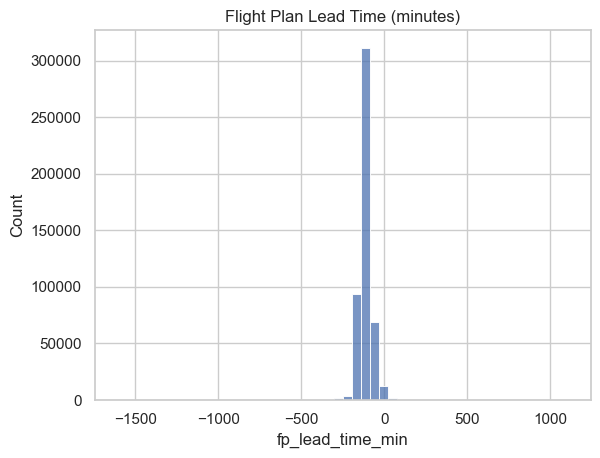

count    494753.000000
mean       -121.623406
std          40.205297
min       -1608.616183
25%        -134.092450
50%        -130.554550
75%        -104.964683
max        1107.577767
Name: fp_lead_time_min, dtype: float64

In [10]:
sns.histplot(df_filtertest['fp_lead_time_min'], bins=50)
plt.title("Flight Plan Lead Time (minutes)")
plt.show()

df_filtertest['fp_lead_time_min'].describe()

In [11]:
# Remove flights with positive lead time (flight plan created after scheduled departure)
df_timestamp = df_filtertest[df_filtertest['fp_lead_time_min'] <= 0].copy()
print("After removing flights with positive lead time:", df_timestamp.shape)

df_90min = df_timestamp[df_timestamp['fp_lead_time_min'] <= -90].copy()
print("After removing flights with lead time less than -90 min:", df_90min.shape)
df_90min['fp_lead_time_min'].describe()

After removing flights with positive lead time: (490959, 79)
After removing flights with lead time less than -90 min: (407096, 79)


count    407096.000000
mean       -135.381668
std          26.925208
min       -1608.616183
25%        -141.049217
50%        -132.380133
75%        -124.537063
max         -90.000267
Name: fp_lead_time_min, dtype: float64

In [ ]:
for col in cols_to_filter:
    plt.figure(figsize=(8,4))
    sns.histplot(df_90min[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

df_90min.describe()

In [13]:
# Check if any flights have non-unique flight_leg_key
duplicate_keys_0 = df_timestamp[df_timestamp.duplicated(subset=['flight_leg_key'], keep=False)]
print("Number of duplicate flight_leg_keys:", duplicate_keys_0.shape[0])

duplicate_keys_90 = df_90min[df_90min.duplicated(subset=['flight_leg_key'], keep=False)]
print("Number of duplicate flight_leg_keys:", duplicate_keys_90.shape[0])

Number of duplicate flight_leg_keys: 26
Number of duplicate flight_leg_keys: 18


In [12]:
# Remove flights with non-unique flight leg keys (potential duplicates)
df_unique_90 = df_90min.drop_duplicates(subset=['flight_leg_key'])
print("After removing duplicate flight leg keys:", df_unique_90.shape)

df_unique_0 = df_timestamp.drop_duplicates(subset=['flight_leg_key'])
print("After removing duplicate flight leg keys:", df_unique_0.shape)

After removing duplicate flight leg keys: (407087, 79)
After removing duplicate flight leg keys: (490946, 79)


In [14]:
# Save cleaned and filtered dataset for modeling
PROJECT_ROOT = Path(r"C:\Users\k454047\OneDrive - Air France KLM\Desktop\THESIS\Code Test")
output_path = PROJECT_ROOT / "data" / "processed" / "klm_cleaned_data_2023_2026(0).parquet"
df_unique_0.to_parquet(output_path, index=False)

PROJECT_ROOT = Path(r"C:\Users\k454047\OneDrive - Air France KLM\Desktop\THESIS\Code Test")
output_path = PROJECT_ROOT / "data" / "processed" / "klm_cleaned_data_2023_2026(-90).parquet"
df_unique_90.to_parquet(output_path, index=False)

In [ ]:
# Print number of flights from October 2023 to September 2025
# df_90min['fl_scheduled_departure_date_utc'] = pd.to_datetime(df_90min['fl_scheduled_departure_date_utc'], errors='coerce')
start_date = pd.to_datetime("2023-10-01")
end_date = pd.to_datetime("2025-09-30")
flights_in_range = df_90min[(df_90min['fl_scheduled_departure_date_utc'] >= start_date) & (df_90min['fl_scheduled_departure_date_utc'] <= end_date)]
print(f"Number of flights from October 2023 to September 2025: {flights_in_range.shape[0]}")

# Print number of flights from October 2025 to December 2025
start_date = pd.to_datetime("2025-10-01")
end_date = pd.to_datetime("2025-12-31")
flights_in_range = df_90min[(df_90min['fl_scheduled_departure_date_utc'] >= start_date) & (df_90min['fl_scheduled_departure_date_utc'] <= end_date)]
print(f"Number of flights from October 2025 to December 2025: {flights_in_range.shape[0]}")

# Print number of flights from January 2026 to March 2026
start_date = pd.to_datetime("2026-01-01")
end_date = pd.to_datetime("2026-03-31")
flights_in_range = df_90min[(df_90min['fl_scheduled_departure_date_utc'] >= start_date) & (df_90min['fl_scheduled_departure_date_utc'] <= end_date)]
print(f"Number of flights from January 2026 to March 2026: {flights_in_range.shape[0]}")

Data Exploration Figures

In [ ]:
target = 'fl_touchdown_delay_min'
df_AMS_in = df_90min[df_90min['fl_actual_arrival_airport'] == 'AMS']
df_AMS_out = df_90min[df_90min['fl_departure_airport'] == 'AMS']
print("Shape of AMS arrivals:", df_AMS_in.shape)
print("Shape of AMS departures:", df_AMS_out.shape)

# Define bin edges (adjust max if needed)
bins = np.arange(0, df_AMS_in['fl_great_circle_distance_nm'].max() + 500, 500)

# Create labels
labels = [f"{int(bins[i])}-{int(bins[i+1])} nm" for i in range(len(bins)-1)]

# Apply binning
df_AMS_in['distance_bin'] = pd.cut(
    df_AMS_in['fl_great_circle_distance_nm'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

plt.figure(figsize=(12,5))

sns.boxplot(
    data=df_AMS_in,
    x='distance_bin',
    y='fl_block_delay_difference_min'
)

plt.xticks(rotation=45)
plt.title("Block Delay by Distance Bin (500 NM)")
plt.xlabel("Distance Bin")
plt.ylabel("Block Delay (min)")
plt.show()

counts = df_AMS_in['distance_bin'].value_counts().sort_index()
print(counts)

# sns.scatterplot(
#     data=df_AMS,
#     x='fl_great_circle_distance_nm',
#     y=target,
#     alpha=0.4
# )

# sns.regplot(
#     data=df_AMS,
#     x='fl_great_circle_distance_nm',
#     y=target,
#     scatter=False,
#     color='red'
# )

top_airports = df_AMS_in['fl_departure_airport'].value_counts().nlargest(10).index

plt.figure(figsize=(10,5))

sns.boxplot(
    data=df_AMS_in[df_AMS_in['fl_departure_airport'].isin(top_airports)],
    x='fl_departure_airport',
    y=target
)

plt.xticks(rotation=45)
plt.title("Block Delay by Departure Airport (Top 10)")
plt.show()

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_90min,
    x='fl_flight_product',
    y=target
)

plt.title("Block Delay by Flight Product")
plt.show()

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_90min,
    x='fl_season',
    y=target
)

plt.title("Block Delay by Season")
plt.show()

top_stars = df_AMS_in['fl_star'].value_counts().nlargest(10).index

plt.figure(figsize=(10,5))

sns.boxplot(
    data=df_AMS_in[df_AMS_in['fl_star'].isin(top_stars)],
    x='fl_star',
    y=target
)

plt.xticks(rotation=45)
plt.title("Block Delay by top 10 STARs")
plt.show()

# Print number of flights in each of the top 10 STARs
star_counts = df_AMS_in['fl_star'].value_counts().loc[top_stars]
print("Number of flights in top 10 STARs:")
print(star_counts)

# top_runway = df_AMS['fp_planned_arrival_runway'].value_counts().nlargest(10).index

plt.figure(figsize=(10,5))

sns.boxplot(
    data=df_AMS_in,
    x='fp_planned_arrival_runway',
    y=target
)

plt.xticks(rotation=45)
plt.title("Block Delay by Planned Arrival Runway")
plt.show()

runway_counts = df_AMS_in['fp_planned_arrival_runway'].value_counts().loc[df_AMS_in['fp_planned_arrival_runway']]
print("Number of flights in top planned arrival runways:")
print(runway_counts)


# Bar chart comparing average block delay difference by aircraft type
plt.figure(figsize=(12, 6))
sns.barplot(x='fl_aircraft_type', y='fl_block_delay_difference_min', data=df_90min, estimator=np.mean, ci=None)
plt.title('Average Block Delay Difference by Aircraft Type')
plt.xlabel('Aircraft Type')
plt.ylabel('Average Block Delay Difference (min)') 
plt.xticks(rotation=45)
plt.show()

# Box plot of block delay difference by departure hour
plt.figure(figsize=(12, 6))
sns.boxplot(x='departure_hour', y='fl_block_delay_difference_min', data=df_AMS_in)
plt.title('Block Delay Difference by Departure Hour')
plt.xlabel('Departure Hour')
plt.ylabel('Block Delay Difference (min)')
plt.show()

# Scatter plot of block delay difference vs cost index
plt.figure(figsize=(10, 6))
sns.scatterplot(x='fp_cost_index', y='fl_block_delay_difference_min', data=df_90min, alpha=0.5)
plt.title('Block Delay Difference vs Cost Index')
plt.xlabel('Cost Index')
plt.ylabel('Block Delay Difference (min)')
plt.show()

# Scatter plot of block delay difference vs scheduled block time
plt.figure(figsize=(10, 6))
sns.scatterplot(x='fl_scheduled_block_time_min', y='fl_block_delay_difference_min', data=df_90min, alpha=0.5)
plt.title('Block Delay Difference vs Scheduled Block Time')
plt.xlabel('Scheduled Block Time (min)')
plt.ylabel('Block Delay Difference (min)')
plt.show()


5. Flight Frequency Analysis

In [ ]:
# Show top departure airports to Schiphol
top_departure_airports = df_AMS_in['fl_departure_airport'].value_counts().head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=top_departure_airports.values, y=top_departure_airports.index)
plt.title("Top Departure Airports to Schiphol")
plt.xlabel("Number of Flights")
plt.ylabel("Departure Airport")
plt.show()

# Show top arrival airports from Schiphol
top_arrival_airports = df_AMS_out['fl_actual_arrival_airport'].value_counts().head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=top_arrival_airports.values, y=top_arrival_airports.index)
plt.title("Top Arrival Airports from Schiphol")
plt.xlabel("Number of Flights")
plt.ylabel("Arrival Airport")
plt.show()

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df_AMS_in['actual_arrival_hour'], bins=24)
plt.title("Arrival Hour Distribution (AMS)")
plt.xticks(range(0,24))
plt.show()

# Print number of flights in each arrival hour bin
arrival_hour_counts = df_AMS_in['actual_arrival_hour'].value_counts().sort_index()
print("Number of flights in each arrival hour bin:")
print(arrival_hour_counts)

plt.figure(figsize=(10,5))
sns.histplot(df_AMS_out['departure_hour'], bins=24)
plt.title("Departure Hour Distribution (AMS)")
plt.xticks(range(0,24))
plt.show()

# Print number of flights in each departure hour bin
departure_hour_counts = df_AMS_out['departure_hour'].value_counts().sort_index()
print("Number of flights in each departure hour bin:")
print(departure_hour_counts)

Departure day and month

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=df_90min, x='departure_dayofweek',
              order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title("Flights per Day of Week")
plt.xticks(rotation=45)
plt.show()

# Number of flights per month
plt.figure(figsize=(10,5))
sns.countplot(data=df_90min, x='departure_month')
plt.title("Flights per Month")
plt.xticks(rotation=45)
plt.show()

9. Long Flights

In [ ]:
long_flights = df_90min[df_90min['fl_actual_trip_duration_min'] > 
                          df_90min['fl_actual_trip_duration_min'].quantile(0.9)]

print("Top aircraft types for long flights:")
print(long_flights['fl_aircraft_type'].value_counts().head())

print("Top routes:")
print(long_flights['fl_city_pair'].value_counts().head())

12. Missing Data

In [ ]:
missing = df_90min.isnull().mean().sort_values(ascending=False)

plt.figure(figsize=(10,8))
missing.head(30).plot(kind='barh')
plt.title("Top Missing Features")
plt.show()

14. Congestion Proxy

In [ ]:
# Count arrivals per 15-minute window
df_AMS_in['arrival_time_rounded'] = df_AMS_in['fl_actual_in_block_time_utc'].dt.floor('15min')

traffic = df_AMS_in.groupby('arrival_time_rounded').size().reset_index(name='num_arrivals')

plt.figure(figsize=(12,5))
plt.plot(traffic['arrival_time_rounded'], traffic['num_arrivals'])
plt.title("Arrival Traffic Over Time")
plt.show()

# Merge back as feature
df_AMS_in = df_AMS_in.merge(traffic, on='arrival_time_rounded', how='left')

15. Aircraft Type

In [ ]:
top_aircraft = df_90min['fl_aircraft_type'].value_counts().head(10)

sns.barplot(x=top_aircraft.values, y=top_aircraft.index)
plt.title("Aircraft Type Distribution")
plt.show()

16. Runway Usage

In [ ]:
sns.countplot(data=df_AMS_in, y='fp_planned_arrival_runway',
              order=df_AMS_in['fp_planned_arrival_runway'].value_counts().index[:10])
plt.title("Planned Runway Usage")
plt.show()

17. EXTRA

In [ ]:
# ==========================================
# 0. Setup
# ==========================================
df = df_90min.copy()

# Ensure datetime
df['fl_scheduled_in_block_time_utc'] = pd.to_datetime(
    df['fl_scheduled_in_block_time_utc'], errors='coerce'
)

# ==========================================
# 1. FILTER: Only Schiphol arrivals
# ==========================================
df = df[df['fl_planned_arrival_airport'] == 'AMS'].copy()

# ==========================================
# 2. CREATE TIME BIN (arrival-based)
# ==========================================
BIN_SIZE = '15min'

df['arrival_bin'] = df['fl_scheduled_in_block_time_utc'].dt.floor(BIN_SIZE)

# ==========================================
# 3. TRAFFIC: TMA ARRIVALS PER BIN
# ==========================================
arrivals_per_bin = (
    df.groupby('arrival_bin')
    .size()
    .rename('num_arrivals_bin')
)

# Create continuous time index
full_index = pd.date_range(
    start=arrivals_per_bin.index.min(),
    end=arrivals_per_bin.index.max(),
    freq=BIN_SIZE
)

arrivals_ts = arrivals_per_bin.reindex(full_index, fill_value=0).to_frame()
arrivals_ts.index.name = 'arrival_bin'

# ==========================================
# 4. ROLLING CONGESTION FEATURES
# ==========================================
windows = [10, 20, 30, 60, 75, 90, 120]

for w in windows:
    arrivals_ts[f'tma_arrivals_{w}min'] = (
        arrivals_ts['num_arrivals_bin']
        .rolling(f'{w}min')
        .sum()
        .shift(1)   # avoid leakage
    )

# ==========================================
# 5. MERGE BACK
# ==========================================
for w in windows:
    df = df.merge(
        arrivals_ts[[f'tma_arrivals_{w}min']],
        left_on='arrival_bin',
        right_index=True,
        how='left'
    )

# ==========================================
# 6. CONGESTION TREND
# ==========================================
df['tma_congestion_trend'] = (df['tma_arrivals_30min'] + 1) / (df['tma_arrivals_90min'] + 1)

df['congestion_acceleration'] = (df['tma_arrivals_10min'] + 1) / (df['tma_arrivals_30min'] + 1)
# ==========================================
# 7. NORMALIZED CONGESTION
# ==========================================
# Average arrivals per hour (baseline)
# hourly_avg = (
#     df.groupby(df['fl_scheduled_in_block_time_utc'].dt.hour)
#     .size()
#     .mean()
# )

hourly_avg = (
    df.groupby(df['fl_scheduled_in_block_time_utc'].dt.hour)
    .size()
    .groupby(level=0)
    .mean()
)

df['hour'] = df['fl_scheduled_in_block_time_utc'].dt.hour

df['tma_arrivals_hour_avg'] = df['fl_scheduled_in_block_time_utc'].dt.hour.map(hourly_avg)

df['tma_arrivals_normalized'] = (
    df['tma_arrivals_90min'] / df['tma_arrivals_hour_avg']
)

# df['tma_arrivals_normalized'] = (
#     df['tma_arrivals_90min'] / hourly_avg
# )

# ==========================================
# 8. FLOW FEATURES
# ==========================================

# 8.1 Inbound direction traffic (proxy: region)
# df['inbound_direction_traffic'] = (
#     df.groupby(['arrival_bin', 'fl_flight_product'])['flight_leg_key']
#     .transform('count')
# )

df['inbound_direction_traffic'] = (
    df.groupby(['arrival_bin', 'fl_city_pair'])['flight_leg_key']
    .transform('count')
)

# 8.2 Arrival wave size (±15 min window)
df['arrival_wave_size'] = (
    df.groupby('arrival_bin')['flight_leg_key']
    .transform('count')
)

# ==========================================
# 9. SPACING BETWEEN ARRIVALS
# ==========================================
df = df.sort_values('fl_scheduled_in_block_time_utc')

# df['time_to_previous_arrival_min'] = (
#     df['fl_scheduled_in_block_time_utc']
#     .diff()
#     .dt.total_seconds() / 60
# )

df['time_to_previous_arrival_min'] = (
    df['fl_scheduled_in_block_time_utc']
    .diff()
    .dt.total_seconds() / 60
)

# Replace zeros (same timestamps) with small epsilon or NaN
df['time_to_previous_arrival_min'] = df['time_to_previous_arrival_min'].replace(0, 0.1)

# Optional: cap extreme values (robustness)
df['time_to_previous_arrival_min'] = df['time_to_previous_arrival_min'].clip(0, 180)

# ==========================================
# 10. FLIGHT FEATURE: CONGESTION BY DISTANCE
# ==========================================
df['congestion_by_distance'] = (
    df['tma_arrivals_90min'] / df['fl_great_circle_distance_nm']
)

# Avoid division issues
df['congestion_by_distance'] = df['congestion_by_distance'].replace([np.inf, -np.inf], np.nan)
df['congestion_by_distance'] = df['congestion_by_distance'].clip(0, 0.3)

# ==========================================
# 11. FINAL CLEANING (important for ML)
# ==========================================
df_features = df.dropna(subset=[
    'tma_arrivals_30min',
    'tma_arrivals_60min',
    'tma_arrivals_90min',
    'tma_arrivals_120min',
    'congestion_by_distance',
    'congestion_acceleration',
    'time_to_previous_arrival_min'
]).copy()

# ==========================================
# 12. QUICK CHECK
# ==========================================
print("Final feature dataset shape:", df_features.shape)

display(df_features[[
    'tma_arrivals_30min',
    'tma_arrivals_60min',
    'tma_arrivals_90min',
    'tma_arrivals_120min',
    'tma_congestion_trend',
    'tma_arrivals_normalized',
    'inbound_direction_traffic',
    'arrival_wave_size',
    'time_to_previous_arrival_min',
    'congestion_by_distance',
    'congestion_acceleration'
]].describe())

In [ ]:
corr = df_features.corr(numeric_only=True)['fl_touchdown_delay_min'].sort_values()
print(corr.tail(10))

corr_traffic = df_features[[
    'fl_touchdown_delay_min',
    'fl_great_circle_distance_nm',
    'tma_arrivals_30min',
    'tma_arrivals_60min',
    'tma_arrivals_90min',
    'tma_arrivals_120min',
    'tma_congestion_trend',
    'tma_arrivals_normalized',
    'inbound_direction_traffic',
    'arrival_wave_size',
    'time_to_previous_arrival_min',
    'congestion_by_distance',
    'congestion_acceleration'
]].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_traffic, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

features = [
    'tma_arrivals_30min',
    'tma_arrivals_60min',
    'tma_arrivals_90min',
    'tma_arrivals_120min',
    'tma_congestion_trend',
    'inbound_direction_traffic',
    'arrival_wave_size',
    'time_to_previous_arrival_min',
    'congestion_by_distance',
    'congestion_acceleration'
]

X = df_features[features]
y = df_features['fl_touchdown_delay_min']

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print(importances)

In [ ]:
df['traffic_x_wave'] = df['tma_arrivals_90min'] * df['arrival_wave_size']
df['traffic_x_spacing'] = df['tma_arrivals_90min'] / df['time_to_previous_arrival_min']

df['congestion_level'] = pd.qcut(df['tma_arrivals_90min'], 5, labels=False)

sns.boxplot(x='congestion_level', y='fl_trip_duration_deviation_min', data=df)

In [ ]:
# PROPER FUNCTION

def build_congestion_features(
    df_input,
    bin_size='15min',
    windows=[15, 30, 45, 60, 90],
    target='fl_block_delay_difference_min'
):
    """
    Builds congestion features (arrivals/departures) using time bins and rolling windows.
    
    Returns:
        df_out: dataframe with congestion features
        corr_df: correlation results for window selection
    """
    
    import pandas as pd
    import numpy as np
    
    df = df_input.copy()
    
    # ===============================
    # 1. Ensure datetime format
    # ===============================
    df['fl_scheduled_off_block_time_utc'] = pd.to_datetime(
        df['fl_scheduled_off_block_time_utc'], errors='coerce'
    )
    df['fl_scheduled_in_block_time_utc'] = pd.to_datetime(
        df['fl_scheduled_in_block_time_utc'], errors='coerce'
    )
    
    # ===============================
    # 2. Create time bins
    # ===============================
    df['sobt_bin'] = df['fl_scheduled_off_block_time_utc'].dt.floor(bin_size)
    df['sibt_bin'] = df['fl_scheduled_in_block_time_utc'].dt.floor(bin_size)
    
    # ===============================
    # 3. Aggregate traffic per bin
    # ===============================
    dep_traffic = (
        df.groupby('sobt_bin')
        .size()
        .rename('num_departures_bin')
    )
    
    arr_traffic = (
        df.groupby('sibt_bin')
        .size()
        .rename('num_arrivals_bin')
    )
    
    # ===============================
    # 4. Create continuous time index
    # ===============================
    full_index = pd.date_range(
        start=min(dep_traffic.index.min(), arr_traffic.index.min()),
        end=max(dep_traffic.index.max(), arr_traffic.index.max()),
        freq=bin_size
    )
    
    dep_ts = dep_traffic.reindex(full_index, fill_value=0).to_frame()
    arr_ts = arr_traffic.reindex(full_index, fill_value=0).to_frame()
    
    dep_ts.index.name = 'sobt_bin'
    arr_ts.index.name = 'sibt_bin'
    
    # ===============================
    # 5. Rolling congestion features
    # ===============================
    for w in windows:
        window_str = f"{w}min"
        
        dep_ts[f'dep_{w}min'] = (
            dep_ts['num_departures_bin']
            .rolling(window_str)
            .sum()
            .shift(1)   # prevent data leakage
        )
        
        arr_ts[f'arr_{w}min'] = (
            arr_ts['num_arrivals_bin']
            .rolling(window_str)
            .sum()
            .shift(1)
        )
    
    # ===============================
    # 6. Merge back to flights
    # ===============================
    df_out = df.copy()
    
    for w in windows:
        df_out = df_out.merge(
            dep_ts[[f'dep_{w}min']],
            left_on='sobt_bin',
            right_index=True,
            how='left'
        )
        
        df_out = df_out.merge(
            arr_ts[[f'arr_{w}min']],
            left_on='sibt_bin',
            right_index=True,
            how='left'
        )
    
    # ===============================
    # 7. Correlation analysis
    # ===============================
    corr_results = []
    
    for w in windows:
        corr_arr = df_out[f'arr_{w}min'].corr(df_out[target])
        corr_dep = df_out[f'dep_{w}min'].corr(df_out[target])
        
        corr_results.append({
            'window_min': w,
            'arrivals_corr': corr_arr,
            'departures_corr': corr_dep
        })
    
    corr_df = pd.DataFrame(corr_results)
    
    # ===============================
    # 8. Select best window
    # ===============================
    best_arr_window = corr_df.loc[
        corr_df['arrivals_corr'].abs().idxmax(), 'window_min'
    ]
    
    best_dep_window = corr_df.loc[
        corr_df['departures_corr'].abs().idxmax(), 'window_min'
    ]
    
    # ===============================
    # 9. Final ML features
    # ===============================
    df_out['traffic_arrivals'] = df_out[f'arr_{best_arr_window}min']
    df_out['traffic_departures'] = df_out[f'dep_{best_dep_window}min']
    
    return df_out, corr_df

In [ ]:
# Drop the actual block time and actual trip duration to avoid spurious correlations
df_corr = df.drop(columns=['fl_actual_block_time_min', 'fl_actual_trip_duration_min'], errors='ignore')

corr_cols = [
    'fl_scheduled_block_time_min',
    'fl_flight_plan_trip_duration_min',
    'fp_lead_time_min',
    'fl_great_circle_distance_nm', 
    'fp_cost_index',
    'fl_prev_leg_arrival_delay_min',
    'fl_touchdown_delay_min',
    'traffic_arrivals',
    'traffic_departures'
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# delay by departure hour

sns.boxplot(data=df_90min, x='departure_hour', y='fl_touchdown_delay_min')
plt.title("Delay by Departure Hour")
plt.show()

sns.boxplot(data=df_AMS_in, x='arrival_hour', y='fl_touchdown_delay_min')
plt.title("Delay by Arrival Hour (AMS)")
plt.show()

In [ ]:
# route level delay

route_delay = df_90min.groupby('fl_city_pair')['fl_touchdown_delay_min'].mean().sort_values(ascending=False)

route_delay.head(10)

In [ ]:
# planned vs actual traffic
# Step 1: Create rounded time
df_filtered['planned_arrival_time_rounded'] = (
    df_filtered['fl_scheduled_in_block_time_utc'].dt.floor('15min')
)

# Step 2: Aggregate
planned_num_arrivals = (
    df_filtered.groupby('planned_arrival_time_rounded')
    .size()
    .reset_index(name='fp_planned_num_arrivals')
)

# Step 3: Remove old column if exists
df_filtered = df_filtered.drop(columns=['fp_planned_num_arrivals'], errors='ignore')

# Step 4: Merge
df_filtered = df_filtered.merge(
    planned_num_arrivals,
    on='planned_arrival_time_rounded',
    how='left'
)

sns.scatterplot(
    data=df_filtered.sample(300),
    x='num_arrivals',
    y='fp_planned_num_arrivals'
)

plt.title("Planned vs Actual Traffic")
plt.show()

df_filtered['traffic_difference'] = (
    df_filtered['num_arrivals'] - df_filtered['fp_planned_num_arrivals']
)

sns.histplot(df_filtered['traffic_difference'], bins=50)
plt.title("Traffic Difference (Actual - Planned)")
plt.show()

# is congestion linked to delay?
sns.scatterplot(
    data=df_filtered.sample(300),
    x='traffic_difference',
    y='fl_arrival_delay_difference_min'
)
plt.title("Unexpected Traffic vs Delay")
plt.show()

df_filtered.head()